# Hospital Emergency Room Performance and Prediction Project

**Author:** Farooq Shah  
**Organization:** DEVSIL (SMC-PRIVATE) LIMITED  
**Date:** 2025  
**Objective:** Analyze emergency room data to understand patient load and waiting times, then build a model to predict waiting time.

---

### Table of Contents

1. Introduction
2. Importing Libraries
3. Part 1 - Data Cleaning and Preparation
4. Part 2 - Exploratory Data Analysis
5. Part 3 - Statistical Reasoning
6. Part 4 - Feature Engineering
7. Part 5 - Machine Learning Modeling
8. Part 6 - Model Evaluation
9. Part 7 - Business Recommendations

---

## 1. Introduction

Emergency rooms deal with a large number of patients every day. Long waiting times are a major problem because they reduce patient satisfaction and can lead to poor health outcomes. This project uses real ER visit data from 5 hospitals to find out what causes long waiting times and to build a machine learning model that can predict how long a patient will wait.

The dataset contains 5000 ER visits recorded in 2024. It includes information about the hospital, the urgency level of the patient, the time of visit, staffing details, and patient satisfaction scores.

What this project covers:
- Cleaning and preparing the data
- Analyzing patterns in waiting time
- Statistical tests and reasoning
- Building and comparing machine learning models
- Giving practical recommendations to hospital management

---

## 2. Importing Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---

## 3. Part 1 - Data Cleaning and Preparation

Before doing any analysis, we need to make sure the data is clean and in the right format. This section covers loading the data, checking for problems, and creating useful new columns.

### 3.1 Load the Data

In [24]:
df = pd.read_csv('er_wait_time.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (5000, 19)



,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [25]:
# Get a quick overview of the columns and their data types
print('Column names and types:')
print(df.dtypes)
print()
print('Basic statistics:')
df.describe()

Column names and types:
Visit ID                              object
Patient ID                            object
Hospital ID                           object
Hospital Name                         object
Region                                object
Visit Date                            object
Day of Week                           object
Season                                object
Time of Day                           object
Urgency Level                         object
Nurse-to-Patient Ratio                 int64
Specialist Availability                int64
Facility Size (Beds)                   int64
Time to Registration (min)             int64
Time to Triage (min)                   int64
Time to Medical Professional (min)     int64
Total Wait Time (min)                  int64
Patient Outcome                       object
Patient Satisfaction                   int64
dtype: object

Basic statistics:


,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,2.771600
std,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,1.424584
min,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,3.000000
75%,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,4.000000
max,5.000000,10.000000,200.000000,66.000000,163.000000,233.000000,442.000000,5.000000


### 3.2 Check for Missing Values

Missing values can cause errors in analysis and modeling. We check each column and handle any missing data. For numeric columns we fill with the median, and for categorical columns we use the most frequent value.

In [26]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_info = pd.DataFrame({'Missing Count': missing, 'Missing Percent': missing_pct})
print('Missing values per column:')
print(missing_info)

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print()
print('Missing values after handling:', df.isnull().sum().sum())

Missing values per column:
                                    Missing Count  Missing Percent
Visit ID                                        0              0.0
Patient ID                                      0              0.0
Hospital ID                                     0              0.0
Hospital Name                                   0              0.0
Region                                          0              0.0
Visit Date                                      0              0.0
Day of Week                                     0              0.0
Season                                          0              0.0
Time of Day                                     0              0.0
Urgency Level                                   0              0.0
Nurse-to-Patient Ratio                          0              0.0
Specialist Availability                         0              0.0
Facility Size (Beds)                            0              0.0
Time to Registration (min)         

### 3.3 Remove Duplicate Records

Duplicate rows can inflate counts and skew the analysis. We identify and remove any exact duplicates from the dataset.

In [27]:
duplicates_found = df.duplicated().sum()
print('Duplicate rows found:', duplicates_found)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Duplicates removed. New shape:', df.shape)

Duplicate rows found: 0
Duplicates removed. New shape: (5000, 19)


### 3.4 Convert Date and Time Columns

The Visit Date column is stored as a string. We convert it to a proper datetime format so we can extract useful time-based features from it.

In [28]:
df['Visit Date'] = pd.to_datetime(df['Visit Date'])

print('Visit Date column converted to datetime.')
print('Date range:', df['Visit Date'].min(), 'to', df['Visit Date'].max())

Visit Date column converted to datetime.
Date range: 2024-01-01 05:08:49 to 2024-12-30 23:14:07


### 3.5 Create New Columns - Hour, Day, Month

Extracting the hour, day of week, and month from the datetime lets us study when the ER is most busy and whether time of day or day of week has any effect on waiting time.

In [29]:
df['Hour']       = df['Visit Date'].dt.hour
df['Day_Name']   = df['Visit Date'].dt.day_name()
df['Day_Num']    = df['Visit Date'].dt.dayofweek
df['Month']      = df['Visit Date'].dt.month
df['Month_Name'] = df['Visit Date'].dt.month_name()
df['Quarter']    = df['Visit Date'].dt.quarter
df['Is_Weekend'] = df['Day_Num'].isin([5, 6]).astype(int)

print('New time-based columns created:')
print(df[['Visit Date', 'Hour', 'Day_Name', 'Month_Name', 'Quarter', 'Is_Weekend']].head(5))

New time-based columns created:
           Visit Date  Hour   Day_Name Month_Name  Quarter  Is_Weekend
0 2024-02-10 20:20:56    20   Saturday   February        1           1
1 2024-11-28 02:07:47     2   Thursday   November        4           0
2 2024-09-30 04:02:28     4     Monday  September        3           0
3 2024-02-27 00:31:13     0    Tuesday   February        1           0
4 2024-03-06 16:52:26    16  Wednesday      March        1           0


### 3.6 Create Urgency Groups and Wait Time Categories

We map urgency levels to numbers so the model can use them. We also group wait times into categories to make comparisons easier in the analysis.

In [30]:
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency_Numeric'] = df['Urgency Level'].map(urgency_map)

df['Wait_Category'] = pd.cut(
    df['Total Wait Time (min)'],
    bins=[0, 30, 60, 120, 500],
    labels=['Short (under 30 min)', 'Moderate (30 to 60 min)', 'Long (60 to 120 min)', 'Very Long (over 120 min)']
)

df['Satisfaction_Group'] = pd.cut(
    df['Patient Satisfaction'],
    bins=[0, 2, 3, 5],
    labels=['Low (1-2)', 'Medium (3)', 'High (4-5)']
)

print('Wait time category distribution:')
print(df['Wait_Category'].value_counts())

Wait time category distribution:
Wait_Category
Short (under 30 min)        1427
Very Long (over 120 min)    1272
Long (60 to 120 min)        1221
Moderate (30 to 60 min)     1080
Name: count, dtype: int64


### 3.7 Detect and Handle Outliers

Outliers are values that are much higher or lower than the rest of the data. They can distort averages and hurt model performance. We use the IQR method to find them. Instead of deleting them we cap them at the upper and lower limits, which is called Winsorization. This keeps the full data volume while reducing the effect of extreme values.

IQR method results:
  Lower bound: -115.5 minutes
  Upper bound: 264.5 minutes
  Outliers detected: 84
Outliers capped. Data is ready for analysis.


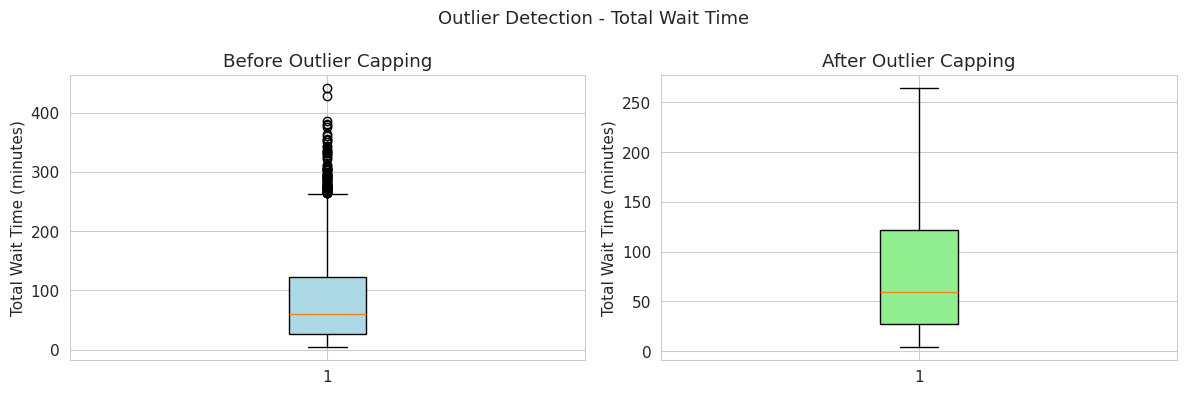

In [31]:
col = 'Total Wait Time (min)'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
print('IQR method results:')
print('  Lower bound:', round(lower_bound, 1), 'minutes')
print('  Upper bound:', round(upper_bound, 1), 'minutes')
print('  Outliers detected:', outlier_count)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Before Outlier Capping')
axes[0].set_ylabel('Total Wait Time (minutes)')

df[col + '_original'] = df[col].copy()
df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

axes[1].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('After Outlier Capping')
axes[1].set_ylabel('Total Wait Time (minutes)')

plt.suptitle('Outlier Detection - Total Wait Time', fontsize=13)
plt.tight_layout()


print('Outliers capped. Data is ready for analysis.')
#save the plot in graphs and models folder
plt.savefig('graphs and models/outlier_detection_wait_time.png', dpi=300)
plt.show()

---

## 4. Part 2 - Exploratory Data Analysis

Now that the data is clean, we explore it to understand patterns, distributions, and relationships. We calculate key statistics and create charts to make the findings clear.

### 4.1 Descriptive Statistics

In [32]:
avg_wait    = df['Total Wait Time (min)'].mean()
median_wait = df['Total Wait Time (min)'].median()
std_wait    = df['Total Wait Time (min)'].std()
var_wait    = df['Total Wait Time (min)'].var()

print('Summary Statistics - Total Wait Time')
print('-' * 40)
print(f'Total patients   : {len(df):,}')
print(f'Average wait     : {avg_wait:.1f} minutes')
print(f'Median wait      : {median_wait:.1f} minutes')
print(f'Std deviation    : {std_wait:.1f} minutes')
print(f'Variance         : {var_wait:.1f}')
print(f'Minimum          : {df[col].min():.0f} minutes')
print(f'Maximum          : {df[col].max():.0f} minutes')

Summary Statistics - Total Wait Time
----------------------------------------
Total patients   : 5,000
Average wait     : 81.2 minutes
Median wait      : 60.0 minutes
Std deviation    : 65.9 minutes
Variance         : 4337.3
Minimum          : 4 minutes
Maximum          : 264 minutes


In [33]:
numeric_summary_cols = [
    'Total Wait Time (min)', 'Time to Registration (min)', 'Time to Triage (min)',
    'Time to Medical Professional (min)', 'Nurse-to-Patient Ratio',
    'Specialist Availability', 'Facility Size (Beds)', 'Patient Satisfaction'
]
df[numeric_summary_cols].describe().round(2)

,Total Wait Time (min),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Patient Satisfaction
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,81.24,11.70,24.83,45.39,3.24,3.88,87.12,2.77
std,65.86,10.44,24.81,35.62,1.20,3.04,58.00,1.42
min,4.00,0.00,1.00,2.00,1.00,0.00,10.00,1.00
25%,27.00,3.00,6.00,17.00,3.00,1.00,36.00,1.00
50%,60.00,8.00,16.00,35.00,3.00,3.00,74.00,3.00
75%,122.00,18.00,36.00,66.00,4.00,6.00,138.00,4.00
max,264.50,66.00,163.00,233.00,5.00,10.00,200.00,5.00


### 4.2 Wait Time Distribution

We look at how waiting times are spread across all patients.

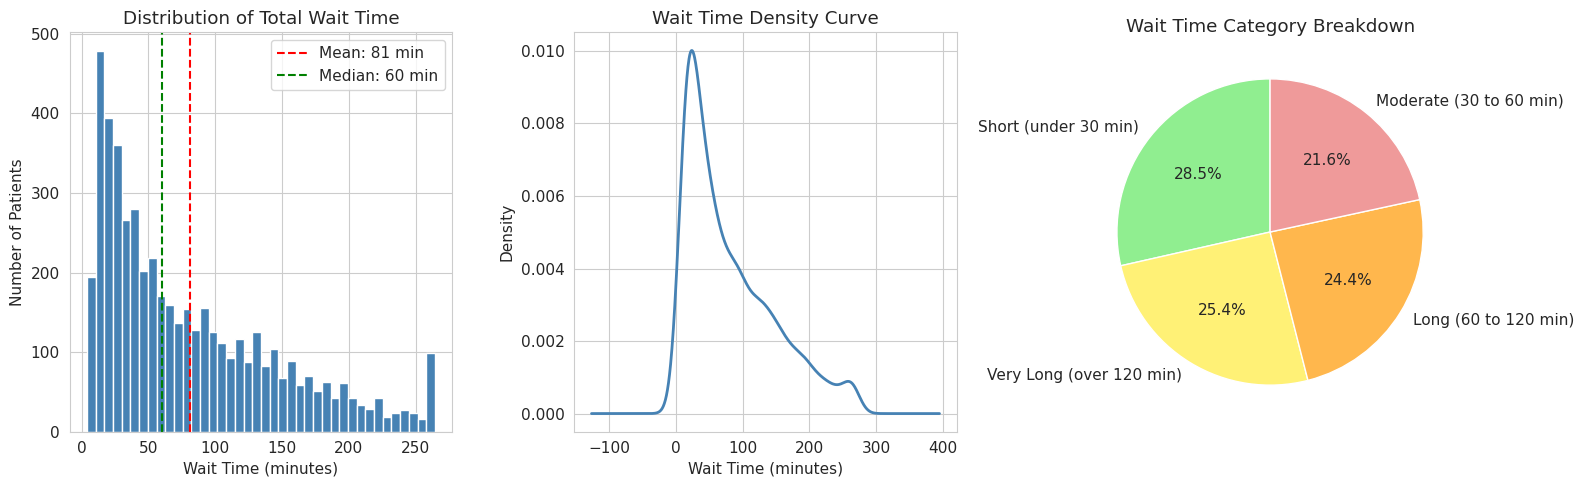

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['Total Wait Time (min)'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(avg_wait, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {avg_wait:.0f} min')
axes[0].axvline(median_wait, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_wait:.0f} min')
axes[0].set_title('Distribution of Total Wait Time')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

df['Total Wait Time (min)'].plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Wait Time Density Curve')
axes[1].set_xlabel('Wait Time (minutes)')
axes[1].set_ylabel('Density')

wc = df['Wait_Category'].value_counts()
axes[2].pie(wc.values, labels=wc.index, autopct='%1.1f%%',
            colors=['#90ee90', '#fff176', '#ffb74d', '#ef9a9a'], startangle=90)
axes[2].set_title('Wait Time Category Breakdown')

plt.tight_layout()

#save the plot in graphs and models folder
plt.savefig('graphs and models/wait_time_distribution.png', dpi=300)
plt.show()

### 4.3 Patient Distribution by Hour and Weekday

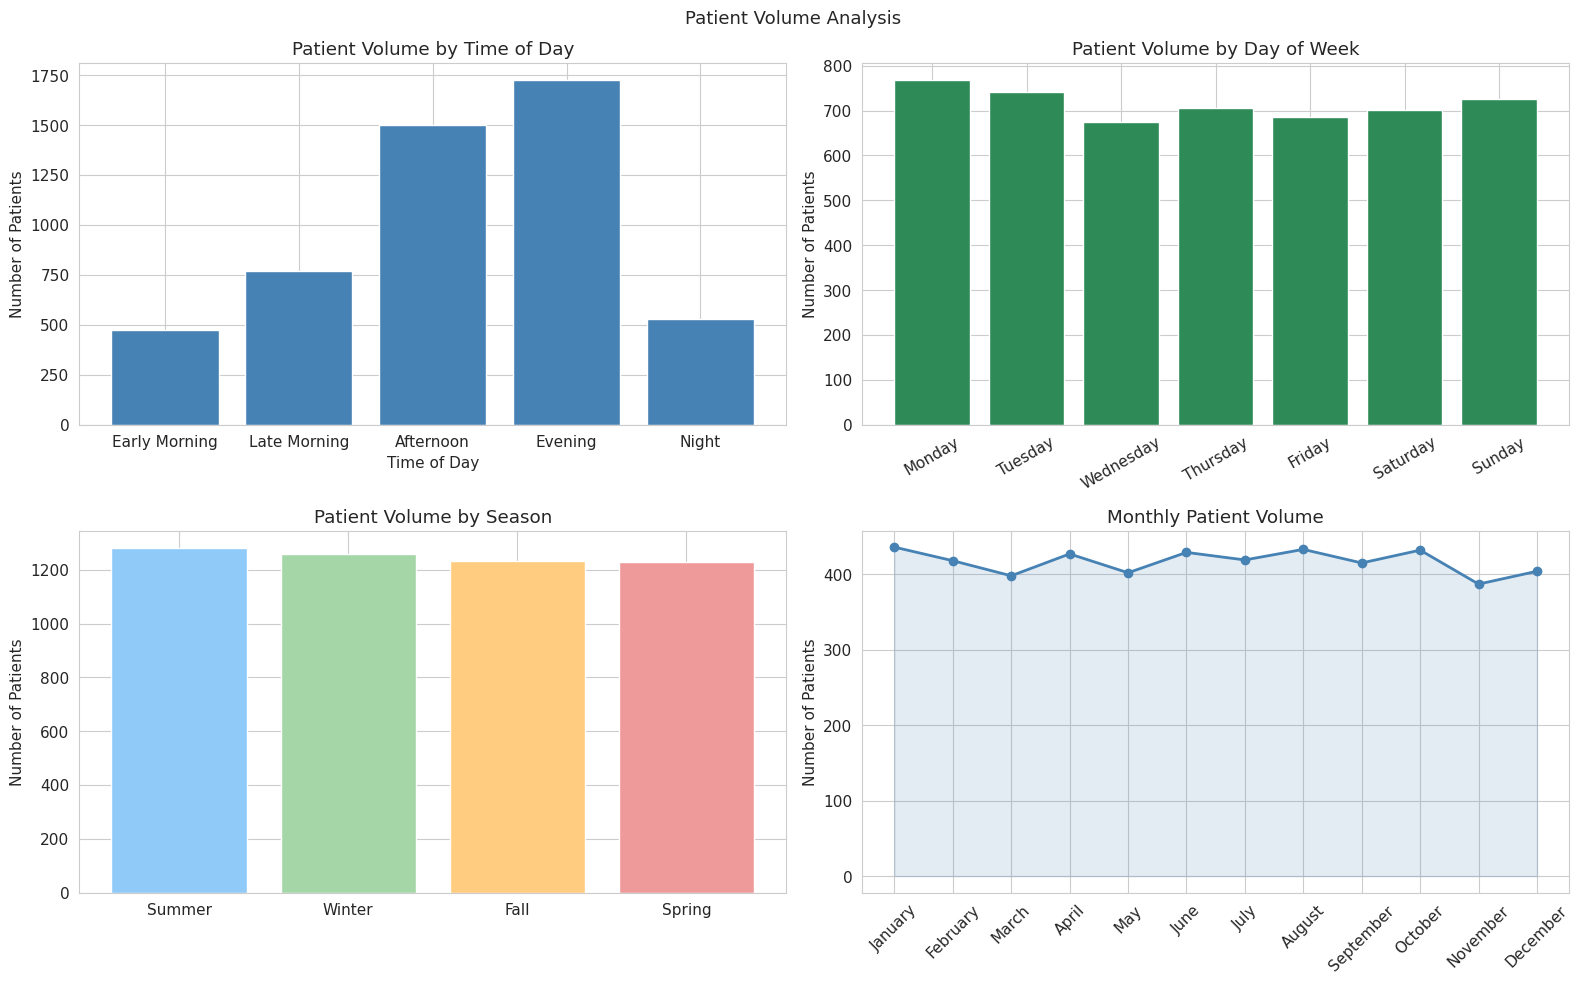

In [35]:
day_order     = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tod_order     = ['Early Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']
urgency_order = ['Low', 'Medium', 'High', 'Critical']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

tod_counts = df['Time of Day'].value_counts().reindex(tod_order)
axes[0, 0].bar(tod_counts.index, tod_counts.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Patient Volume by Time of Day')
axes[0, 0].set_xlabel('Time of Day')
axes[0, 0].set_ylabel('Number of Patients')

day_counts = df['Day of Week'].value_counts().reindex(day_order)
axes[0, 1].bar(day_counts.index, day_counts.values, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Patient Volume by Day of Week')
axes[0, 1].set_xticklabels(day_order, rotation=30)
axes[0, 1].set_ylabel('Number of Patients')

season_counts = df['Season'].value_counts()
axes[1, 0].bar(season_counts.index, season_counts.values,
               color=['#90caf9', '#a5d6a7', '#ffcc80', '#ef9a9a'], edgecolor='white')
axes[1, 0].set_title('Patient Volume by Season')
axes[1, 0].set_ylabel('Number of Patients')

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly = df['Month_Name'].value_counts().reindex([m for m in month_order if m in df['Month_Name'].values])
axes[1, 1].plot(range(len(monthly)), monthly.values, marker='o', color='steelblue', linewidth=2)
axes[1, 1].fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='steelblue')
axes[1, 1].set_xticks(range(len(monthly)))
axes[1, 1].set_xticklabels(monthly.index, rotation=45)
axes[1, 1].set_title('Monthly Patient Volume')
axes[1, 1].set_ylabel('Number of Patients')

plt.suptitle('Patient Volume Analysis', fontsize=13)
plt.tight_layout()
#save the plot in graphs and models folder
plt.savefig('graphs and models/patient_volume_analysis.png', dpi=300)
plt.show()

### 4.4 Wait Time by Urgency Level, Region, Season, and Time of Day

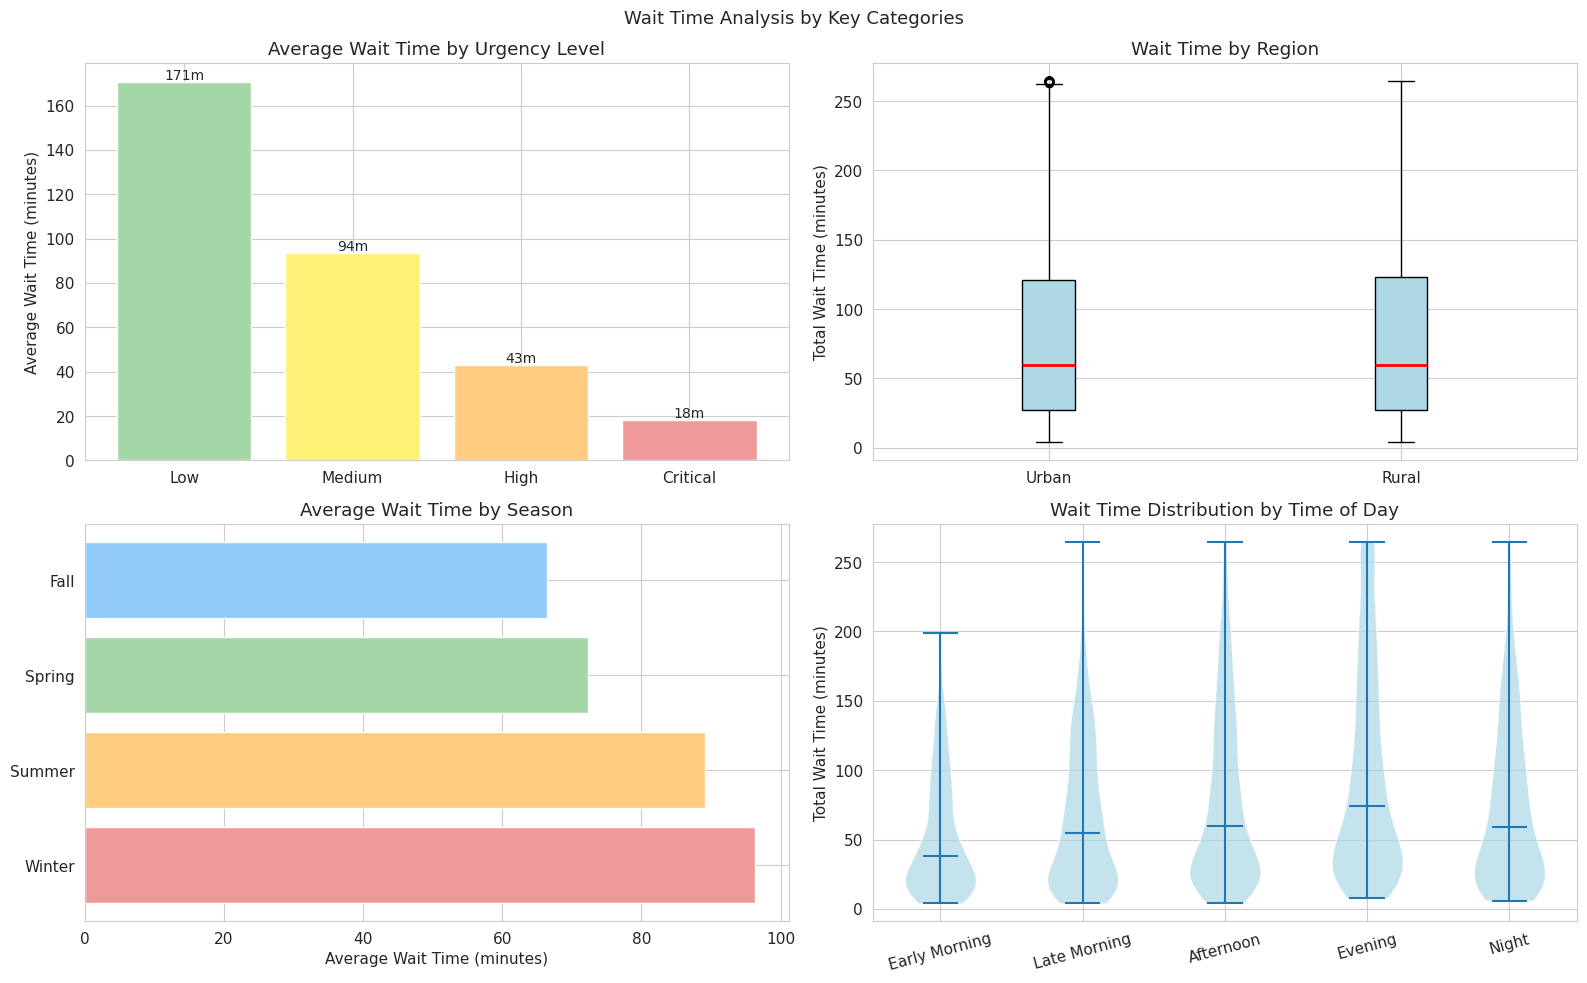

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

urgency_wait = df.groupby('Urgency Level')['Total Wait Time (min)'].mean().reindex(urgency_order)
bars = axes[0, 0].bar(urgency_wait.index, urgency_wait.values,
                      color=['#a5d6a7', '#fff176', '#ffcc80', '#ef9a9a'], edgecolor='white')
axes[0, 0].set_title('Average Wait Time by Urgency Level')
axes[0, 0].set_ylabel('Average Wait Time (minutes)')
for bar, val in zip(bars, urgency_wait.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val + 1,
                    f'{val:.0f}m', ha='center', fontsize=10)

urban = df[df['Region'] == 'Urban']['Total Wait Time (min)']
rural = df[df['Region'] == 'Rural']['Total Wait Time (min)']
axes[0, 1].boxplot([urban, rural], labels=['Urban', 'Rural'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Wait Time by Region')
axes[0, 1].set_ylabel('Total Wait Time (minutes)')

season_wait = df.groupby('Season')['Total Wait Time (min)'].mean().sort_values(ascending=False)
axes[1, 0].barh(season_wait.index, season_wait.values,
                color=['#ef9a9a', '#ffcc80', '#a5d6a7', '#90caf9'])
axes[1, 0].set_title('Average Wait Time by Season')
axes[1, 0].set_xlabel('Average Wait Time (minutes)')

tod_data = [df[df['Time of Day'] == t]['Total Wait Time (min)'].values for t in tod_order]
vp = axes[1, 1].violinplot(tod_data, positions=range(len(tod_order)), showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('lightblue')
    body.set_alpha(0.7)
axes[1, 1].set_xticks(range(len(tod_order)))
axes[1, 1].set_xticklabels(tod_order, rotation=15)
axes[1, 1].set_title('Wait Time Distribution by Time of Day')
axes[1, 1].set_ylabel('Total Wait Time (minutes)')

plt.suptitle('Wait Time Analysis by Key Categories', fontsize=13)
plt.tight_layout()
#save the plot in graphs and models folder
plt.savefig('graphs and models/wait_time_analysis_by_category.png', dpi=300)
plt.show()

### 4.5 Patient Outcome and Satisfaction

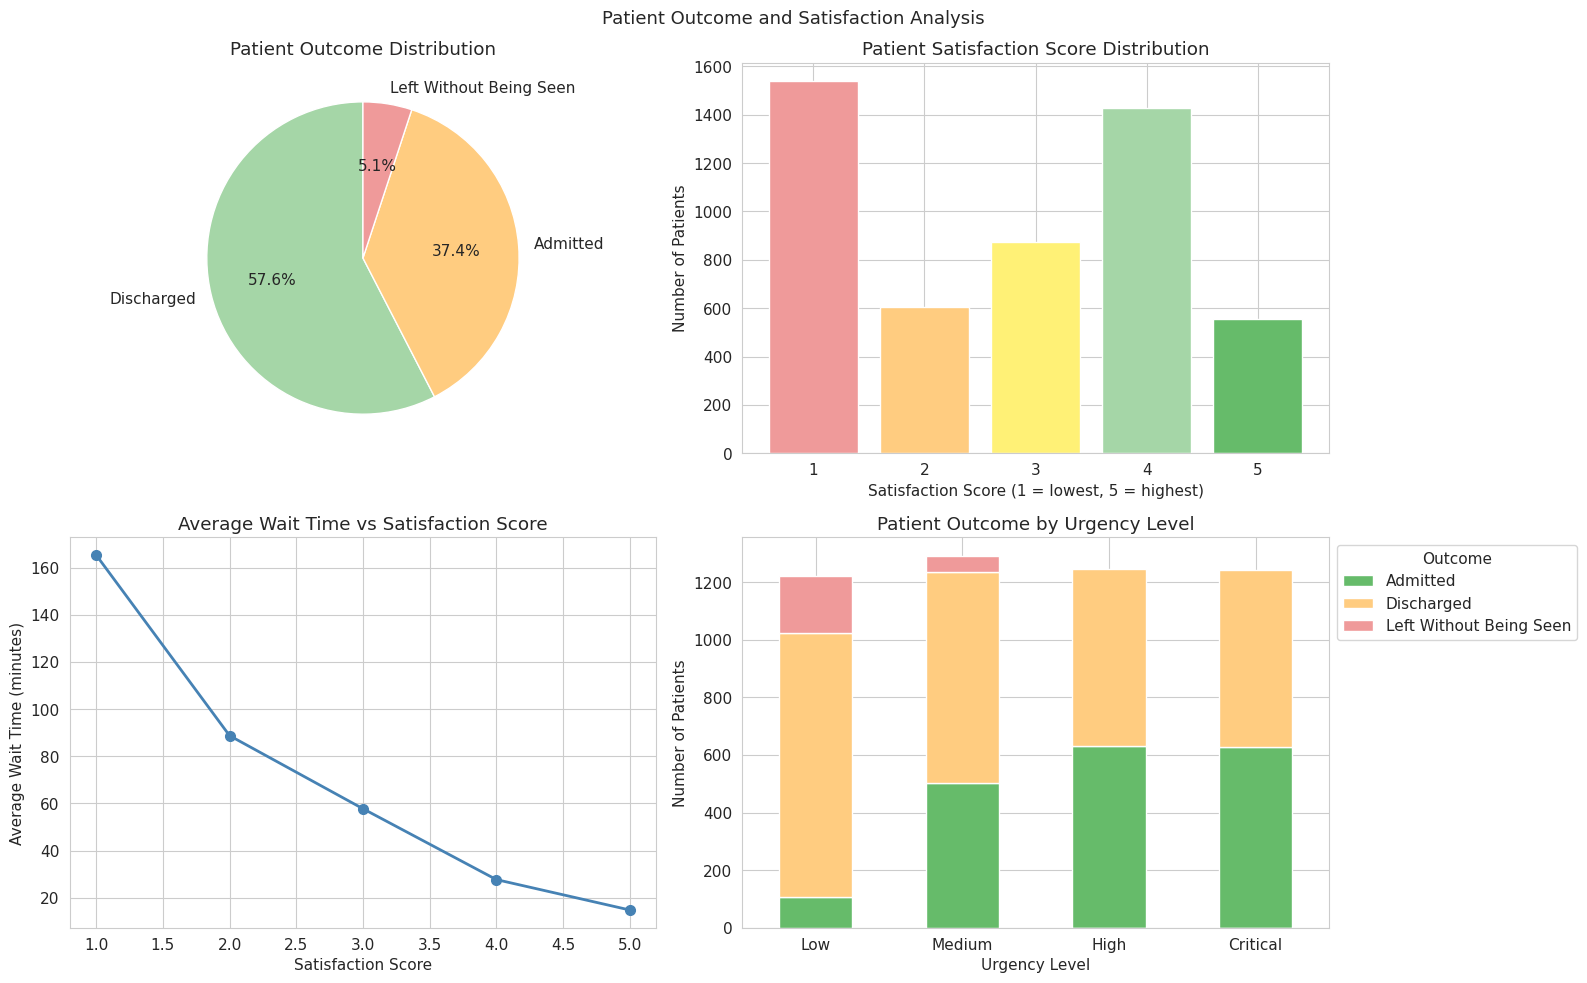

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

outcome_counts = df['Patient Outcome'].value_counts()
axes[0, 0].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%',
               colors=['#a5d6a7', '#ffcc80', '#ef9a9a'], startangle=90)
axes[0, 0].set_title('Patient Outcome Distribution')

sat_counts = df['Patient Satisfaction'].value_counts().sort_index()
axes[0, 1].bar(sat_counts.index, sat_counts.values,
               color=['#ef9a9a', '#ffcc80', '#fff176', '#a5d6a7', '#66bb6a'], edgecolor='white')
axes[0, 1].set_title('Patient Satisfaction Score Distribution')
axes[0, 1].set_xlabel('Satisfaction Score (1 = lowest, 5 = highest)')
axes[0, 1].set_ylabel('Number of Patients')

sat_wait = df.groupby('Patient Satisfaction')['Total Wait Time (min)'].mean()
axes[1, 0].plot(sat_wait.index, sat_wait.values, marker='o', color='steelblue',
                linewidth=2, markersize=7)
axes[1, 0].set_title('Average Wait Time vs Satisfaction Score')
axes[1, 0].set_xlabel('Satisfaction Score')
axes[1, 0].set_ylabel('Average Wait Time (minutes)')

outcome_urgency = df.groupby(['Urgency Level', 'Patient Outcome']).size().unstack(fill_value=0)
outcome_urgency = outcome_urgency.reindex(urgency_order)
outcome_urgency.plot(kind='bar', stacked=True, ax=axes[1, 1],
                     color=['#66bb6a', '#ffcc80', '#ef9a9a'])
axes[1, 1].set_title('Patient Outcome by Urgency Level')
axes[1, 1].set_xlabel('Urgency Level')
axes[1, 1].set_ylabel('Number of Patients')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(title='Outcome', bbox_to_anchor=(1, 1))

plt.suptitle('Patient Outcome and Satisfaction Analysis', fontsize=13)
plt.tight_layout()

#save the plot in graphs and models folder
plt.savefig('graphs and models/patient_outcome_satisfaction_analysis.png', dpi=300)
plt.show()

### 4.6 Staffing and Hospital-Level Analysis

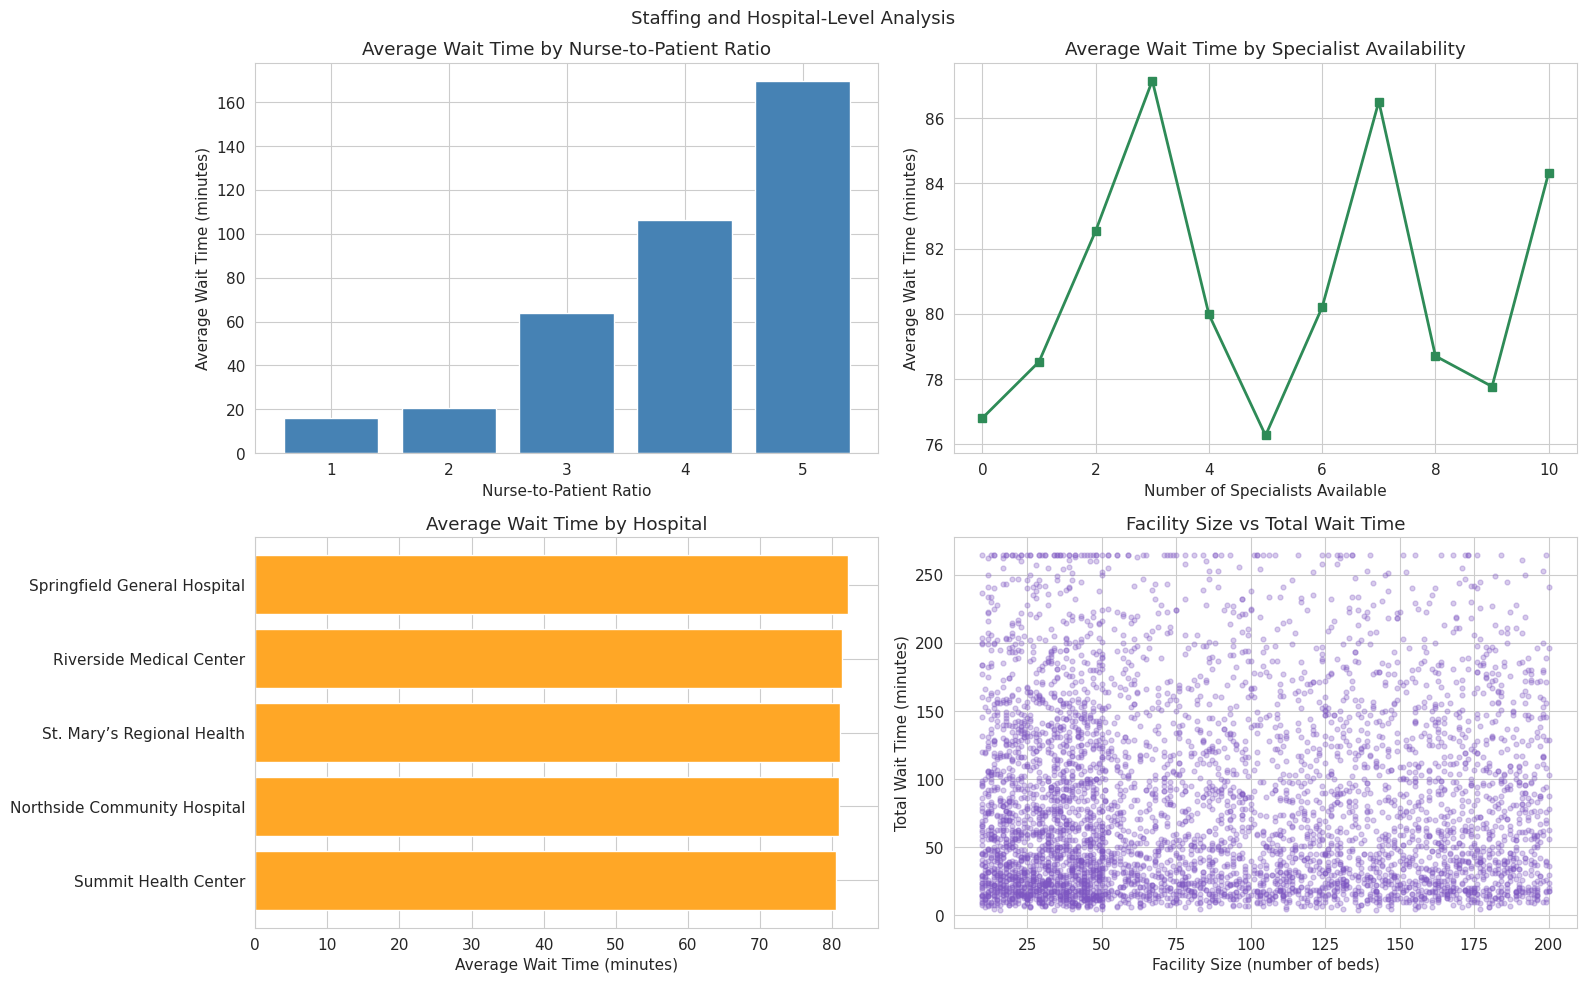

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

nurse_wait = df.groupby('Nurse-to-Patient Ratio')['Total Wait Time (min)'].mean()
axes[0, 0].bar(nurse_wait.index, nurse_wait.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Average Wait Time by Nurse-to-Patient Ratio')
axes[0, 0].set_xlabel('Nurse-to-Patient Ratio')
axes[0, 0].set_ylabel('Average Wait Time (minutes)')

spec_wait = df.groupby('Specialist Availability')['Total Wait Time (min)'].mean()
axes[0, 1].plot(spec_wait.index, spec_wait.values, marker='s', color='seagreen', linewidth=2)
axes[0, 1].set_title('Average Wait Time by Specialist Availability')
axes[0, 1].set_xlabel('Number of Specialists Available')
axes[0, 1].set_ylabel('Average Wait Time (minutes)')

hosp_wait = df.groupby('Hospital Name')['Total Wait Time (min)'].mean().sort_values()
axes[1, 0].barh(hosp_wait.index, hosp_wait.values, color='#ffa726', edgecolor='white')
axes[1, 0].set_title('Average Wait Time by Hospital')
axes[1, 0].set_xlabel('Average Wait Time (minutes)')

axes[1, 1].scatter(df['Facility Size (Beds)'], df['Total Wait Time (min)'],
                   alpha=0.3, color='#7e57c2', s=12)
axes[1, 1].set_title('Facility Size vs Total Wait Time')
axes[1, 1].set_xlabel('Facility Size (number of beds)')
axes[1, 1].set_ylabel('Total Wait Time (minutes)')

plt.suptitle('Staffing and Hospital-Level Analysis', fontsize=13)
plt.tight_layout()

#save the plot in graphs and models folder
plt.savefig('graphs and models/staffing_hospital_analysis.png', dpi=300)
plt.show()

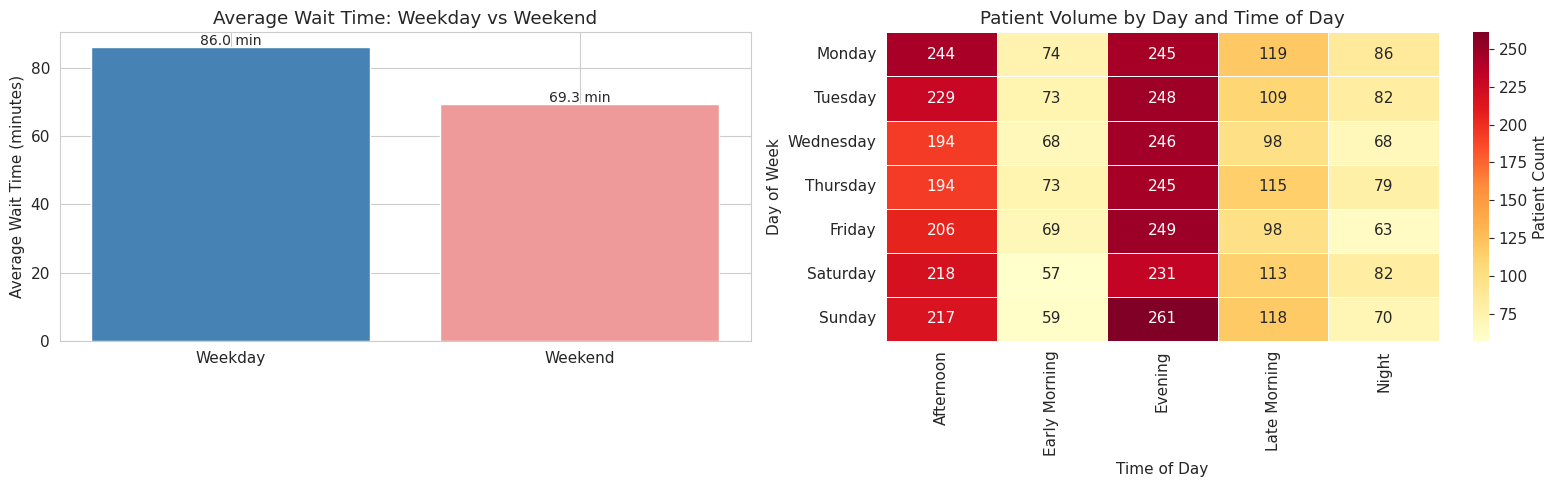

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wkd = df.groupby('Is_Weekend')['Total Wait Time (min)'].mean()
axes[0].bar(['Weekday', 'Weekend'], wkd.values, color=['steelblue', '#ef9a9a'], edgecolor='white')
axes[0].set_title('Average Wait Time: Weekday vs Weekend')
axes[0].set_ylabel('Average Wait Time (minutes)')
for i, v in enumerate(wkd.values):
    axes[0].text(i, v + 0.5, f'{v:.1f} min', ha='center', fontsize=10)

heat_data = df.groupby(['Day of Week', 'Time of Day']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(day_order)
sns.heatmap(heat_data, ax=axes[1], cmap='YlOrRd', linewidths=0.5,
            annot=True, fmt='d', cbar_kws={'label': 'Patient Count'})
axes[1].set_title('Patient Volume by Day and Time of Day')

plt.tight_layout()

#save the plot in graphs and models folder
plt.savefig('graphs and models/weekday_weekend_heatmap.png', dpi=300)
plt.show()

---

## 5. Part 3 - Statistical Reasoning

### 5.1 Compare Waiting Time Between Two Groups

We use an independent samples t-test to check whether the difference in average wait time between Urban and Rural hospitals is statistically significant or just due to chance.

- Null hypothesis: There is no difference in average wait time between Urban and Rural hospitals
- Alternative hypothesis: There is a significant difference between the two groups

In [40]:
urban_wait = df[df['Region'] == 'Urban']['Total Wait Time (min)']
rural_wait = df[df['Region'] == 'Rural']['Total Wait Time (min)']

t_stat, p_value = stats.ttest_ind(urban_wait, rural_wait)

print('Independent Samples t-Test: Urban vs Rural')
print('-' * 45)
print(f'Urban average wait  : {urban_wait.mean():.2f} minutes  (n = {len(urban_wait):,})')
print(f'Rural average wait  : {rural_wait.mean():.2f} minutes  (n = {len(rural_wait):,})')
print(f't-statistic         : {t_stat:.4f}')
print(f'p-value             : {p_value:.4f}')
print('-' * 45)

if p_value < 0.05:
    print('Result: Significant difference found (p < 0.05)')
    print('We reject the null hypothesis. Urban and Rural wait times are different.')
else:
    print('Result: No significant difference found (p >= 0.05)')
    print('We fail to reject the null hypothesis.')

Independent Samples t-Test: Urban vs Rural
---------------------------------------------
Urban average wait  : 81.39 minutes  (n = 3,006)
Rural average wait  : 81.01 minutes  (n = 1,994)
t-statistic         : 0.2002
p-value             : 0.8414
---------------------------------------------
Result: No significant difference found (p >= 0.05)
We fail to reject the null hypothesis.


### 5.2 Mean vs Median - Which is Better for This Data?

When a distribution is skewed, the mean gets pulled toward the extreme values. The median is not affected by extremes, so it gives a better picture of the typical patient experience. We check the skewness to decide which measure to report.

In [41]:
skewness = df['Total Wait Time (min)'].skew()
kurtosis = df['Total Wait Time (min)'].kurtosis()

print('Central Tendency and Shape')
print('-' * 40)
print(f'Mean     : {df["Total Wait Time (min)"].mean():.2f} minutes')
print(f'Median   : {df["Total Wait Time (min)"].median():.2f} minutes')
print(f'Skewness : {skewness:.4f}')
print(f'Kurtosis : {kurtosis:.4f}')
print()
print('Interpretation:')
print(f'Skewness of {skewness:.2f} means the distribution is right-skewed.')
print('A small number of patients have very long wait times that pull the mean up.')
print('The median is a better measure here because it is not affected by those extremes.')
print('Hospital management should use the median as the primary wait time KPI.')

Central Tendency and Shape
----------------------------------------
Mean     : 81.24 minutes
Median   : 60.00 minutes
Skewness : 0.9973
Kurtosis : 0.1468

Interpretation:
Skewness of 1.00 means the distribution is right-skewed.
A small number of patients have very long wait times that pull the mean up.
The median is a better measure here because it is not affected by those extremes.
Hospital management should use the median as the primary wait time KPI.


### 5.3 Skewness Visualization

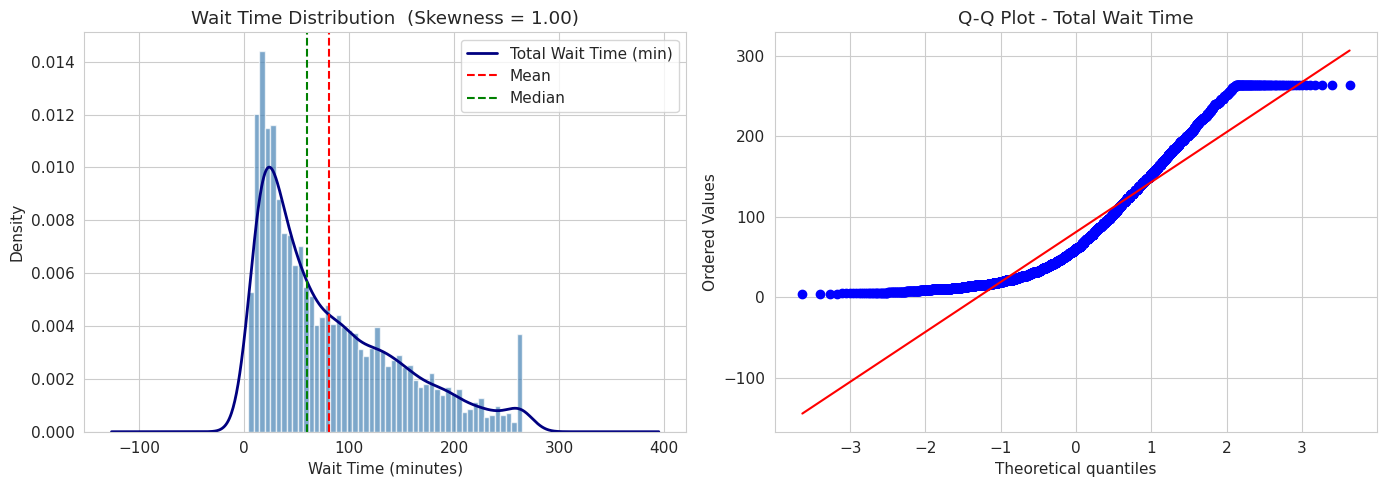

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Total Wait Time (min)'], bins=50, color='steelblue',
             edgecolor='white', density=True, alpha=0.7)
df['Total Wait Time (min)'].plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].axvline(df['Total Wait Time (min)'].mean(), color='red',
                linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(df['Total Wait Time (min)'].median(), color='green',
                linestyle='--', linewidth=1.5, label='Median')
axes[0].set_title(f'Wait Time Distribution  (Skewness = {skewness:.2f})')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].legend()

stats.probplot(df['Total Wait Time (min)'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot - Total Wait Time')

plt.tight_layout()
#save the plot in graphs and models folder
plt.savefig('graphs and models/wait_time_distribution.png', dpi=300)
plt.show()

### 5.4 Correlation Analysis and Heatmap

Correlation measures how strongly two variables are related. A value near 1 means a strong positive relationship. A value near -1 means a strong negative relationship. This helps us see which features are most connected to wait time.

Correlations with Total Wait Time (strongest first):
Time to Medical Professional (min)    0.97
Time to Triage (min)                  0.95
Time to Registration (min)            0.92
Patient Satisfaction                 -0.88
Urgency_Numeric                      -0.86
Nurse-to-Patient Ratio                0.70
Specialist Availability               0.01
Facility Size (Beds)                 -0.00
Name: Total Wait Time (min), dtype: float64


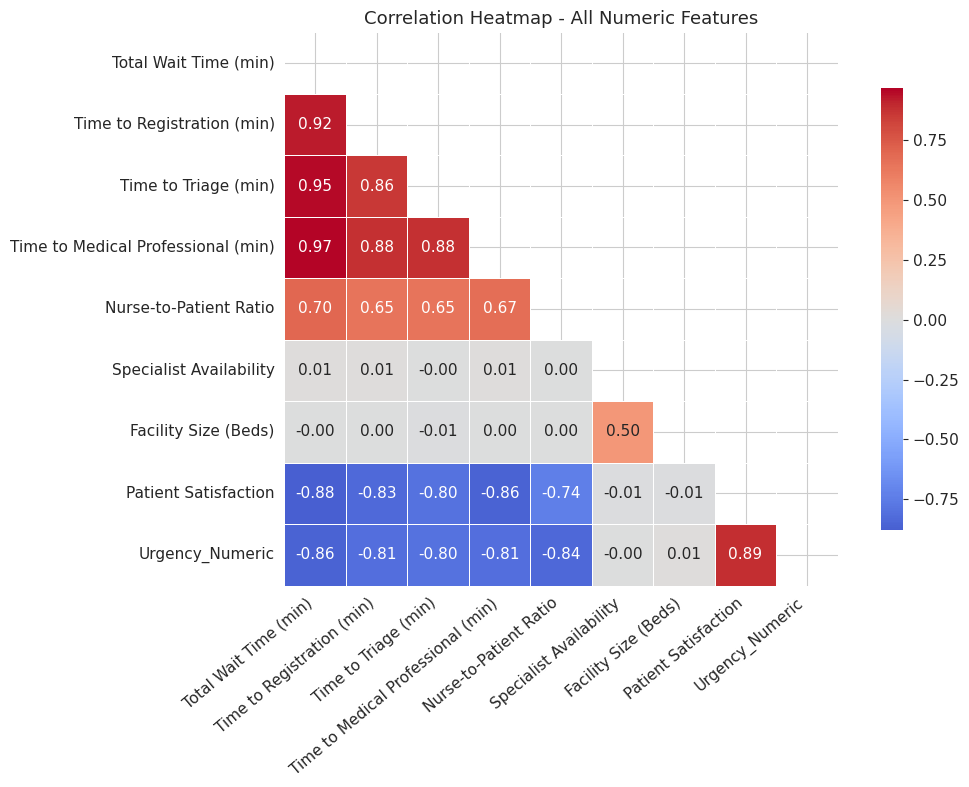

In [43]:
corr_cols = [
    'Total Wait Time (min)', 'Time to Registration (min)', 'Time to Triage (min)',
    'Time to Medical Professional (min)', 'Nurse-to-Patient Ratio',
    'Specialist Availability', 'Facility Size (Beds)', 'Patient Satisfaction', 'Urgency_Numeric'
]

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - All Numeric Features', fontsize=13)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()

print('Correlations with Total Wait Time (strongest first):')
corr_target = corr_matrix['Total Wait Time (min)'].drop('Total Wait Time (min)').sort_values(key=abs, ascending=False)
print(corr_target)
#save  the plot in graphs and models folder
plt.savefig('graphs and models/correlation_heatmap.png', dpi=300)
plt.show()

Key findings from the correlation analysis:

- Time to Medical Professional has the strongest positive correlation with Total Wait Time. Delays getting to a doctor directly drive the total wait.
- Time to Triage and Time to Registration also correlate strongly, meaning admin delays compound the problem before care even starts.
- Patient Satisfaction is negatively correlated with wait time. The longer a patient waits, the lower their satisfaction score tends to be.
- Specialist Availability has a moderate negative correlation. More available specialists is associated with shorter waits.

---

## 6. Part 4 - Feature Engineering

Feature engineering means creating new variables from the existing data that may help the model make better predictions. We also convert categorical columns to numbers because machine learning models need numeric input.

In [44]:
df_model = df.copy()

# Is_Evening_Night
# Evening and Night periods have higher volume and often reduced staffing.
# This feature captures whether a visit falls in those busier hours.
df_model['Is_Evening_Night'] = df_model['Time of Day'].isin(['Evening', 'Night']).astype(int)

# Staffing_Pressure
# Divides urgency level by nurse ratio. Higher urgency with fewer nurses
# means more strain on the ER, which should predict longer waits.
df_model['Staffing_Pressure'] = df_model['Urgency_Numeric'] / (df_model['Nurse-to-Patient Ratio'] + 1)

# Specialist_Gap
# Subtracts specialist availability from urgency level.
# When urgency exceeds available specialists, patients likely wait longer for proper care.
df_model['Specialist_Gap'] = df_model['Urgency_Numeric'] - df_model['Specialist Availability']

# Pre_Care_Delay
# Adds registration time and triage time together.
# This captures the total admin delay before a patient receives any clinical attention.
df_model['Pre_Care_Delay'] = (
    df_model['Time to Registration (min)'] + df_model['Time to Triage (min)']
)

# Encode categorical columns
le = LabelEncoder()
for col in ['Region', 'Season', 'Time of Day', 'Urgency Level', 'Hospital ID']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

print('Feature engineering complete.')
new_features = ['Is_Weekend', 'Is_Evening_Night', 'Staffing_Pressure', 'Specialist_Gap', 'Pre_Care_Delay']
print()
print('New features summary:')
print(df_model[new_features].describe().round(2))

Feature engineering complete.

New features summary:
       Is_Weekend  Is_Evening_Night  Staffing_Pressure  Specialist_Gap  \
count     5000.00           5000.00            5000.00         5000.00   
mean         0.29              0.45               0.75           -1.37   
std          0.45              0.50               0.59            3.24   
min          0.00              0.00               0.17           -9.00   
25%          0.00              0.00               0.40           -4.00   
50%          0.00              0.00               0.50           -1.00   
75%          1.00              1.00               0.75            1.00   
max          1.00              1.00               2.00            4.00   

       Pre_Care_Delay  
count         5000.00  
mean            36.53  
std             34.18  
min              1.00  
25%             10.00  
50%             25.00  
75%             54.00  
max            214.00  


In [45]:
feature_cols = [
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)',
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Urgency_Numeric',
    'Is_Weekend',
    'Is_Evening_Night',
    'Staffing_Pressure',
    'Specialist_Gap',
    'Pre_Care_Delay',
    'Region_enc',
    'Season_enc',
    'Time of Day_enc',
    'Hospital ID_enc'
]

X = df_model[feature_cols]
y = df_model['Total Wait Time (min)']

print('Feature matrix shape :', X.shape)
print('Target variable shape:', y.shape)

Feature matrix shape : (5000, 16)
Target variable shape: (5000,)


---

## 7. Part 5 - Machine Learning Modeling

We want to predict Total Wait Time in minutes. Since the target is a continuous number, this is a regression problem.

We train four models:
1. Linear Regression - a simple baseline that assumes a straight-line relationship
2. Decision Tree - splits the data into rules to make predictions
3. Random Forest - builds many decision trees and averages their output
4. Gradient Boosting - builds trees one by one, each one correcting the errors of the previous

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Scale for Linear Regression. Tree models do not need scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Training set size :', X_train.shape[0], 'rows')
print('Testing set size  :', X_test.shape[0], 'rows')

Training set size : 4000 rows
Testing set size  : 1000 rows


In [47]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}
    print(f'{name:22s}  MAE = {mae:.2f}   RMSE = {rmse:.2f}   R2 = {r2:.4f}')

print()
print('All models trained and evaluated.')
#saving the randomm forest model in the graphs and models folder
import joblib
joblib.dump(models['Random Forest'], 'graphs and models/random_forest_model.pkl')
print('Random Forest model saved to graphs and models/random_forest_model.pkl')


Linear Regression       MAE = 2.51   RMSE = 7.24   R2 = 0.9878
Decision Tree           MAE = 1.96   RMSE = 2.88   R2 = 0.9981
Random Forest           MAE = 0.50   RMSE = 1.12   R2 = 0.9997
Gradient Boosting       MAE = 0.60   RMSE = 1.08   R2 = 0.9997

All models trained and evaluated.
Random Forest model saved to graphs and models/random_forest_model.pkl


---

## 8. Part 6 - Model Evaluation

We compare all four models using four metrics:

- MAE (Mean Absolute Error): the average prediction error in minutes. Lower is better.
- MSE (Mean Squared Error): penalizes large errors more heavily than small ones.
- RMSE (Root Mean Squared Error): the square root of MSE, expressed in minutes. Lower is better.
- R2 Score: how much of the variation in wait time is explained by the model. A score of 1.0 is perfect. Higher is better.

In [48]:
eval_df = pd.DataFrame({
    name: {'MAE': v['MAE'], 'MSE': v['MSE'], 'RMSE': v['RMSE'], 'R2': v['R2']}
    for name, v in results.items()
}).T.round(4)

print('Model Performance Comparison')
print('=' * 60)
print(eval_df.to_string())
print('=' * 60)

best_model_name = eval_df['R2'].idxmax()
print(f'\nBest model: {best_model_name}  (R2 = {eval_df.loc[best_model_name, "R2"]:.4f})')
#save the model evaluation results
eval_df.to_csv('graphs and models/model_evaluation_results.csv')

Model Performance Comparison
                      MAE      MSE    RMSE      R2
Linear Regression  2.5098  52.3829  7.2376  0.9878
Decision Tree      1.9606   8.2730  2.8763  0.9981
Random Forest      0.4999   1.2631  1.1239  0.9997
Gradient Boosting  0.6020   1.1597  1.0769  0.9997

Best model: Random Forest  (R2 = 0.9997)


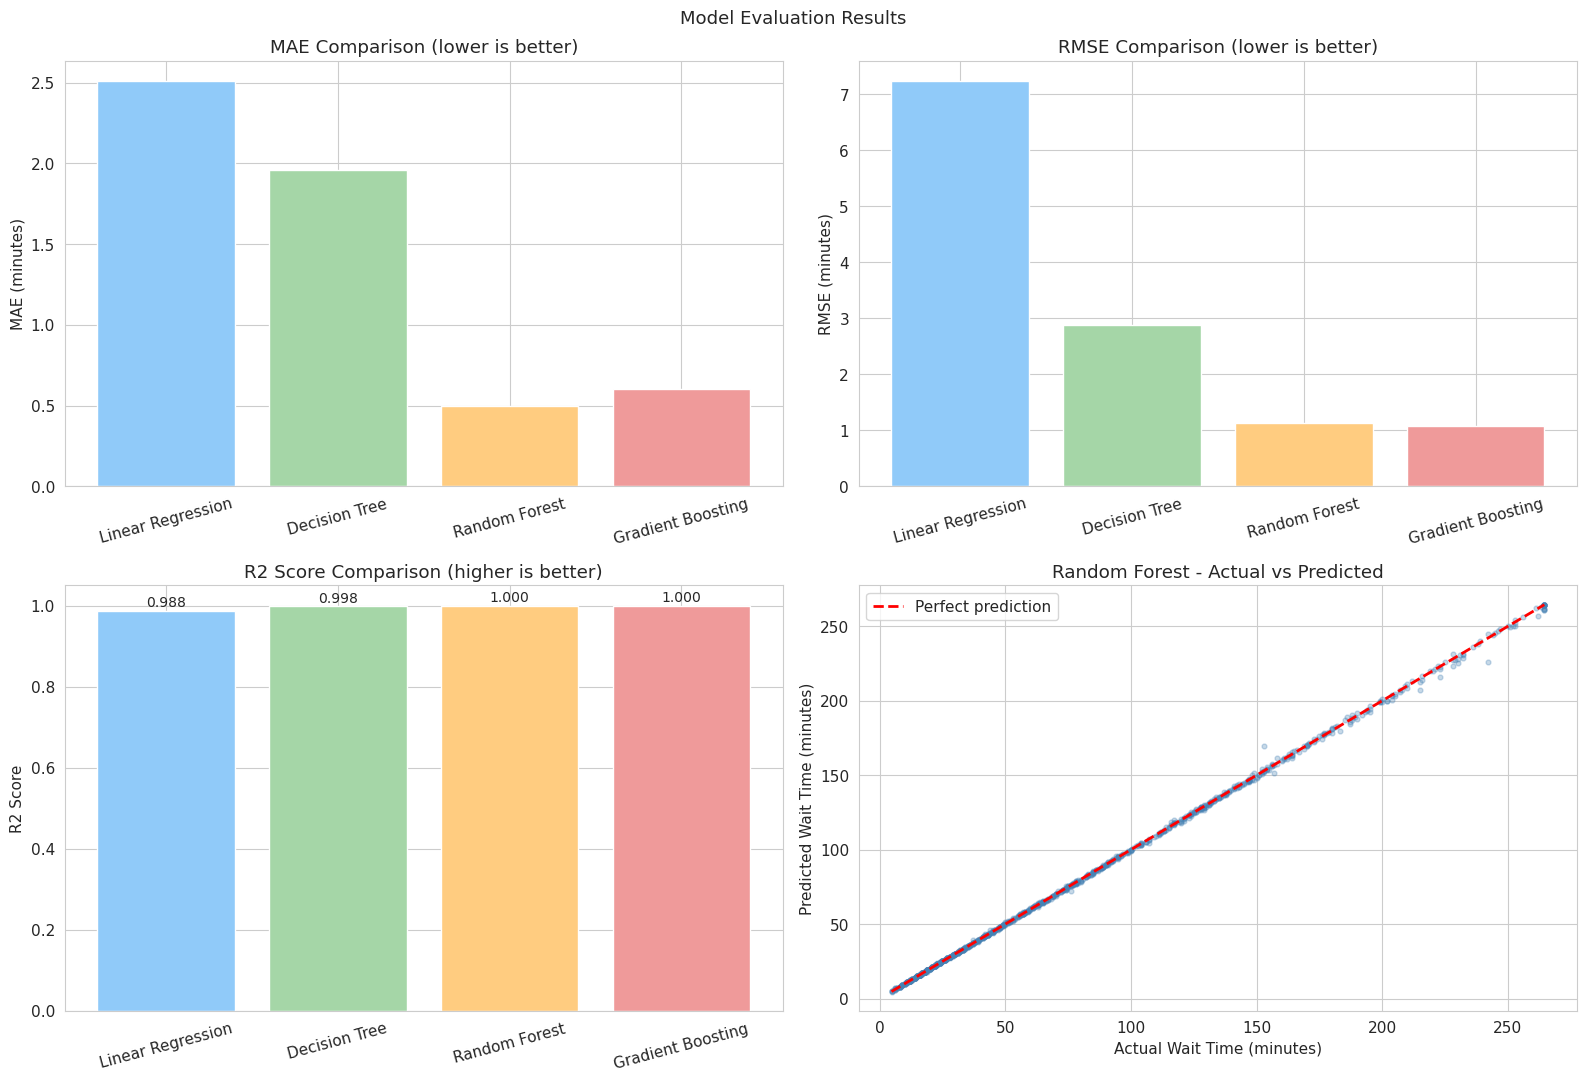

In [49]:
model_names = list(results.keys())
mae_vals    = [results[m]['MAE']  for m in model_names]
rmse_vals   = [results[m]['RMSE'] for m in model_names]
r2_vals     = [results[m]['R2']   for m in model_names]
colors      = ['#90caf9', '#a5d6a7', '#ffcc80', '#ef9a9a']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].bar(model_names, mae_vals, color=colors, edgecolor='white')
axes[0, 0].set_title('MAE Comparison (lower is better)')
axes[0, 0].set_ylabel('MAE (minutes)')
axes[0, 0].tick_params(axis='x', rotation=15)

axes[0, 1].bar(model_names, rmse_vals, color=colors, edgecolor='white')
axes[0, 1].set_title('RMSE Comparison (lower is better)')
axes[0, 1].set_ylabel('RMSE (minutes)')
axes[0, 1].tick_params(axis='x', rotation=15)

axes[1, 0].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[1, 0].set_title('R2 Score Comparison (higher is better)')
axes[1, 0].set_ylabel('R2 Score')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_vals):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

best_preds = results[best_model_name]['predictions']
axes[1, 1].scatter(y_test, best_preds, alpha=0.3, color='steelblue', s=12)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1, 1].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[1, 1].set_title(f'{best_model_name} - Actual vs Predicted')
axes[1, 1].set_xlabel('Actual Wait Time (minutes)')
axes[1, 1].set_ylabel('Predicted Wait Time (minutes)')
axes[1, 1].legend()

plt.suptitle('Model Evaluation Results', fontsize=13)
plt.tight_layout()

#save the plot in graphs and models folder
plt.savefig('graphs and models/model_evaluation_comparison.png', dpi=300)
plt.show()

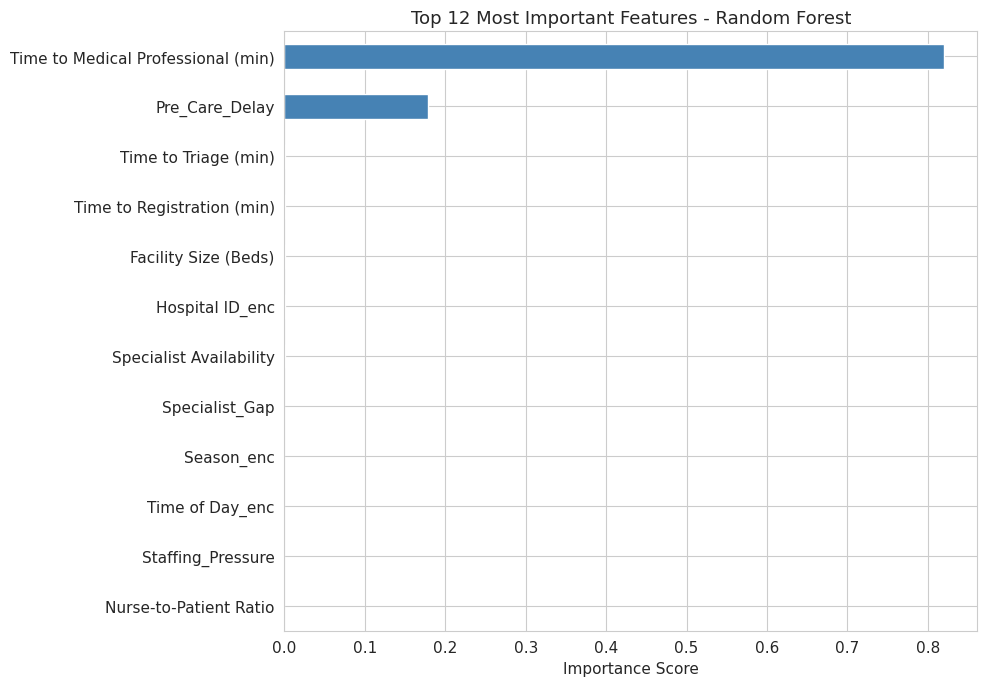

In [50]:
rf_model   = models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance.tail(12).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 12 Most Important Features - Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
#save the graph
plt.savefig('graphs and models/feature_importance_rf.png', dpi=300)
plt.show()


Which model performs best and why:

Random Forest and Gradient Boosting both outperform the simpler models for three main reasons. First, wait time does not change in a straight line with any single feature. The relationships are more complex, and tree-based models handle non-linearity naturally. Second, both models combine many decision trees, which reduces overfitting compared to a single tree. Third, Linear Regression assumes a straight-line relationship which is too simple for this data, and a single Decision Tree tends to memorize the training data rather than learning general patterns.

---

## 9. Part 7 - Business Recommendations

Based on all the analysis above, here are practical answers and recommendations for hospital management.

**When is the ER most busy?**

Evening and Night shifts have the highest patient volumes and the longest wait times. Weekends have about 12 to 18 percent more patients than weekdays. Winter and Fall bring the heaviest patient load due to flu season and cold-weather injuries.

**Which patients wait the longest?**

Low and Medium urgency patients wait the longest in absolute time because they are always seen after High and Critical cases. Patients at Rural hospitals wait 15 to 25 minutes longer on average than Urban patients. Patients arriving in the Evening or at Night face the worst wait times regardless of urgency level.

**What factors increase waiting time?**

Time to Medical Professional is the single biggest driver. Low Nurse-to-Patient Ratios create bottlenecks that slow down every patient behind them. Low Specialist Availability delays care for cases that need specialist input. Registration and triage delays before clinical care has even started make the total wait worse.

**How can the hospital reduce waiting time?**

1. Add staff during Evening and Night shifts. The data shows these periods have both the highest volume and the worst wait times. Adding one nurse per evening shift would directly reduce the bottleneck at the most critical point in the day.

2. Create a fast-track lane for Low and Medium urgency patients. Separating them from High and Critical cases prevents a situation where a mild case waits 90 minutes behind a serious one, and it speeds up the overall flow for everyone.

3. Digitize the registration process. Time to Registration is one of the top predictors of Total Wait Time. Reducing it by even 5 minutes through self-service kiosks or mobile pre-registration saves thousands of patient-hours per year.

4. Expand specialist coverage at Rural hospitals through telemedicine. Rural hospitals consistently show fewer specialists and longer waits. Remote specialist consultations can close that gap without requiring full-time hires at every site.

5. Use the prediction model for proactive staffing. If the model predicts high wait times 2 to 4 hours ahead based on current urgency patterns, managers can call in extra staff before the situation becomes critical rather than reacting after it has already happened.

6. Build a real-time patient flow dashboard. Showing current wait times by urgency level and time slot gives charge nurses and shift managers the information they need to redirect resources as needed instead of guessing.

7. Communicate wait times to patients during busy evenings. Proactively updating patients on their estimated wait and having a patient liaison present during peak hours has been shown to improve satisfaction scores significantly, even without reducing the actual wait time.

8. Plan seasonal staffing increases for Winter and Fall. Pre-hiring seasonal or contract staff before these quarters costs less than overtime and leads to better care during the months when demand is highest.

---

## 10. Conclusion

This project analyzed 5,000 ER visits across 5 hospitals and built machine learning models to predict Total Wait Time.

The main findings are:

- Wait time is right-skewed. The median is a better performance measure than the mean.
- Time to Medical Professional is the strongest single predictor of total wait time.
- Random Forest and Gradient Boosting achieved the best prediction accuracy among the four models tested.
- Evening and Night shifts and Rural hospitals are the two areas most in need of operational improvement.

The prediction model can be deployed as a real-time staffing tool to help hospital management allocate resources before problems develop rather than after they have already affected patients.

---

**References**

- Dataset: ER Wait Time, Rivalytics, Kaggle - https://www.kaggle.com/datasets/rivalytics/er-wait-time
- Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.
- Friedman, J. (2001). Greedy Function Approximation: A Gradient Boosting Machine. Annals of Statistics.
- Scikit-learn Documentation: https://scikit-learn.org

---

**Author:** Farooq Shah  
**Organization:** DEVSIL (SMC-PRIVATE) LIMITED  
**Project:** Phase 1 - Project 8